# Finding the invisible: $W\to\mu\nu$ from truth to missing momentum

The electron, its heavier relatives the muon and tau, and their neutrinos and antiparticles belong to a family of particles called **leptons**. The W boson is a carrier of the weak interaction and can decay into a charged lepton and a neutrino.

A dimuon decay is relatively easy to analyse: the detector can reconstruct both decay products and combine their momenta to infer the mass of their parent particle. A $W\to\mu\nu$ decay poses a more challenging question:

> **How can we learn about a particle when one of its decay products crosses the detector unseen?**

We will use one file from the CMS simulated [W+jets NanoAOD dataset](https://opendata.cern.ch/record/cms-69747). NanoAOD is a compact event format: each entry represents one collision event, and its branches store simulated and reconstructed quantities. Simulation lets us look at generator “truth,” then compare it with what CMS reconstructs.

## Learning goals

By the end, you should be able to:

- compare what a Feynman diagram, the `LHEPart` hard-interaction record, and the `GenPart` generator history show;
- describe how energy and momentum form a four-vector and what transverse momentum $p_T$ measures;
- connect a generated muon to a reconstructed muon and interpret $\Delta R$;
- explain why missing transverse momentum is an inferred vector, not a detected neutrino;
- explain why the neutrino's unknown longitudinal momentum prevents full invariant-mass reconstruction; and
- construct the transverse mass $m_T$ of the $W$ candidate.

Cells labelled **Toolbox** contain machinery needed for the lesson. Run them, but do not worry about every line on a first pass.

## 1. Setup

The setup cell uses an existing local copy when available. Otherwise it downloads the 133 MB file directly from the CERN Open Data Portal. It is safe to run more than once.

In [1]:
# @title Setup: install missing packages and locate or download the ROOT file
from pathlib import Path
import importlib.util
import subprocess
import sys

# Install only dependencies that are missing from the current environment.
required_packages = {"awkward": "awkward==2.12.0", "uproot": "uproot==5.7.5"}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
from IPython.display import Markdown, display

filename = "00702195-E707-3743-8BBA-57EB9DEE1DBA.root"
file_url = (
    "https://opendata.cern.ch/eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/"
    "WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8/NANOAODSIM/"
    "106X_mcRun2_asymptotic_v17-v1/270000/" + filename
)
# Reuse a local copy when available; otherwise download into the working directory.
candidates = [Path("data/69747") / filename, Path("../data/69747") / filename, Path(filename)]
file_path = next((path.resolve() for path in candidates if path.exists()), None)
if file_path is None:
    file_path = Path(filename).resolve()
    subprocess.run(["curl", "-L", "--fail", "--retry", "3", "--output", str(file_path), file_url], check=True)

root_file = uproot.open(file_path)
events = root_file["Events"]
print(f"Uproot {uproot.__version__}; Awkward {ak.__version__}")
print(f"Input: {file_path.name}")
print(f"Events: {events.num_entries:,}")

Uproot 5.7.5; Awkward 2.12.0
Input: 00702195-E707-3743-8BBA-57EB9DEE1DBA.root
Events: 133,692


## 2. From a physics picture to stored particles

In particle physics, we use **Feynman diagrams** to represent particle interactions. The diagrams below show examples of producing a W together with an outgoing quark, followed by W boson decay. The quark can later develop into a **jet**, a narrow spray of particles. Read the diagrams from left to right: straight lines represent quarks or leptons, the curly line a gluon, and the wavy line a W boson.

These diagrams are useful illustrations, but they are not photographs or complete event histories. Several diagrams can contribute to the same process, and a simulated event contains additional particles and interactions that are not shown here.

In [2]:
# @title Representative W production and decay diagrams
from IPython.display import HTML

diagram_base = "https://atlas.physicsmasterclasses.org/wpath_files/img/Feynman"
diagram_cards = [
    ("u + g → d + W⁺ (one-parton example)", f"{diagram_base}/WplusDown.png"),
    ("W⁺ → μ⁺ + νμ", f"{diagram_base}/Wplus_Antimyon.png"),
    ("d + g → u + W⁻ (one-parton example)", f"{diagram_base}/WminusUp.png"),
    ("W⁻ → μ⁻ + ν̄μ", f"{diagram_base}/Wminus_Myon.png"),
]
cards_html = "".join(
    f"<figure style='margin:0;text-align:center'><img src='{url}' alt='{caption}' "
    f"style='width:100%;max-height:260px;object-fit:contain'><figcaption>{caption}</figcaption></figure>"
    for caption, url in diagram_cards
)
HTML(
    f"<div style='display:grid;grid-template-columns:repeat(2,minmax(260px,1fr));gap:18px'>{cards_html}</div>"
    "<p style='font-size:0.85em;color:#475569'>Source and image credit: "
    "<a href='https://atlas.physicsmasterclasses.org/en/wpath_lhcphysics2.htm'>ATLAS W-Path, "
    "International Physics Masterclasses</a>. See the "
    "<a href='https://ippog.org/ippog-copyright'>IPPOG educational-use terms</a>.</p>"
)

| View | What it represents |
| --- | --- |
| Feynman diagram | A simplified drawing used when calculating a particle interaction; it is not a complete event record |
| `LHEPart` | The incoming and outgoing particles in the primary high-energy (or **hard**) interaction |
| `GenPart` | A selected history after later generator steps and decays; repeated copies of one particle may appear |

Notice that a W drawn in a diagram need not appear as its own `LHEPart` row. A diagram illustrates a calculation, while an event record stores selected stages of a simulation. The [branch documentation for this exact file](https://opendata.cern.ch/eos/opendata/cms/dataset-semantics/NanoAODSIM/69747/WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8_doc.html) defines the NanoAOD columns used below.

<details><summary>Technical detail about this W+jets sample</summary>The production and decay panels can be joined at their W line. In the combined calculation, the W is an internal propagator, so `LHEPart` may contain only the external quarks or gluons, charged lepton, and neutrino. The official [process card](https://opendata.cern.ch/eos/opendata/cms/lhe_generators/2016-sim/gridpacks/69747/InputCards/WJetsToLNu_13TeV-madgraphMLM-pythia8_proc_card.dat) includes $pp\to\ell\nu$ with zero to four outgoing matrix-element partons, combined with a parton shower using MLM matching.</details>

### Momentum language used below

Momentum is a three-dimensional vector with components $(p_x,p_y,p_z)$. At the LHC, the $z$ direction follows the proton beams, while $x$ and $y$ span the **transverse plane**, perpendicular to the beams. The transverse momentum is the length of the momentum projected onto that plane:

$$p_T=\sqrt{p_x^2+p_y^2}.$$

The angle $\phi$ gives the direction around the beam axis. The pseudorapidity $\eta$ describes the direction relative to the beam: $\eta=0$ is perpendicular to it, while large $|\eta|$ points closer to it.

In relativity, a particle's energy and momentum are combined into an **energy–momentum four-vector**

$$P=(E,\vec p)=(E,p_x,p_y,p_z),$$

using particle-physics units in which $c=1$. Four-vectors can be added, for example to reconstruct the mass of a parent particle from its decay products.

In [3]:
# @title Toolbox: load only the columns used in this lesson
# NanoAOD collections are jagged: every event can contain a different number of particles.
branches = [
    "event", "LHEPart_pdgId", "LHEPart_status",
    "GenPart_pdgId", "GenPart_status", "GenPart_statusFlags",
    "GenPart_genPartIdxMother", "GenPart_pt", "GenPart_eta", "GenPart_phi", "GenPart_mass",
    "Muon_genPartIdx", "Muon_pt", "Muon_eta", "Muon_phi",
    "GenMET_pt", "GenMET_phi", "MET_pt", "MET_phi",
    "nJet", "Pileup_nTrueInt",
]
data = events.arrays(branches, library="ak")
print(f"Loaded {len(data):,} events and {len(branches)} selected columns")

Loaded 133,692 events and 21 selected columns


## 3. Which leptons does the W produce?

**Predict first:** Although we will later select $W\to\mu\nu_\mu$ events, does this input file contain only that decay channel? Or does it contain all three direct leptonic W decays—$W\to e\nu_e$, $W\to\mu\nu_\mu$, and $W\to\tau\nu_\tau$—in roughly equal numbers?

The cleanest place to classify the original W decay is among the outgoing `LHEPart` particles. This avoids mistaking a later $\tau\to\mu\nu\nu$ decay for a direct W-to-muon decay.

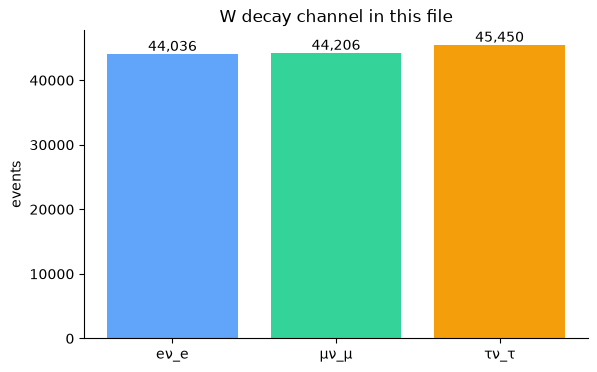

{'eν_e': 44036, 'μν_μ': 44206, 'τν_τ': 45450}

In [4]:
# LHE status 1 denotes outgoing particles from the matrix-element calculation.
lhe_final_abs_id = abs(data.LHEPart_pdgId[data.LHEPart_status == 1])
# Each channel mask contains one True/False value per event.
decay_channels = {
    "eν_e": ak.any(lhe_final_abs_id == 11, axis=1),
    "μν_μ": ak.any(lhe_final_abs_id == 13, axis=1),
    "τν_τ": ak.any(lhe_final_abs_id == 15, axis=1),
}
channel_counts = {name: int(ak.sum(mask)) for name, mask in decay_channels.items()}
assert sum(channel_counts.values()) == len(data)
mu_channel = decay_channels["μν_μ"]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(list(channel_counts), list(channel_counts.values()), color=["#60a5fa", "#34d399", "#f59e0b"])
ax.bar_label(bars, fmt="{:,}")
ax.set(ylabel="events", title="W decay channel in this file")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
channel_counts

> **Takeaway:** the three channels occur in roughly equal numbers, as expected from lepton universality: the W interacts in essentially the same way with the electron, muon, and tau families. This file was generated specifically with leptonic W decays; W decays to quarks are not included. We now keep the direct muon channel.

In [5]:
# @title Toolbox: particle names, angular helpers, and truth/reco selections
PARTICLE_NAMES = {
    1: "d", -1: "d̄", 2: "u", -2: "ū", 3: "s", -3: "s̄", 4: "c", -4: "c̄", 5: "b", -5: "b̄", 21: "g",
    11: "e⁻", -11: "e⁺", 12: "νₑ", -12: "ν̄ₑ", 13: "μ⁻", -13: "μ⁺", 14: "νμ", -14: "ν̄μ",
    15: "τ⁻", -15: "τ⁺", 16: "ντ", -16: "ν̄τ", 22: "γ", 23: "Z", 24: "W⁺", -24: "W⁻",
}

def particle_name(pdg_id):
    return PARTICLE_NAMES.get(int(pdg_id), f"PDG {int(pdg_id)}")

def display_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join("---" for _ in headers) + " |"]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

def has_flag(flags, bit):
    return (flags & (1 << bit)) != 0

def delta_phi(phi1, phi2):
    return (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi

def delta_r(eta1, phi1, eta2, phi2):
    return np.hypot(eta1 - eta2, delta_phi(phi1, phi2))

def transverse_mass(pt1, phi1, pt2, phi2):
    return np.sqrt(2 * pt1 * pt2 * (1 - np.cos(delta_phi(phi1, phi2))))

# Select the stable hard-process muon and muon-neutrino in every direct-muon event.
gen_abs_id = abs(data.GenPart_pdgId)
stable = data.GenPart_status == 1
from_hard_process = has_flag(data.GenPart_statusFlags, 8)
gen_mu_mask = (gen_abs_id == 13) & stable & from_hard_process
gen_nu_mask = (gen_abs_id == 14) & stable & from_hard_process
assert bool(ak.all(ak.num(data.GenPart_pdgId[gen_mu_mask], axis=1)[mu_channel] == 1))
assert bool(ak.all(ak.num(data.GenPart_pdgId[gen_nu_mask], axis=1)[mu_channel] == 1))

# Muon_genPartIdx points back to a row in the GenPart collection.
gen_mu_index = ak.fill_none(ak.firsts(ak.local_index(data.GenPart_pdgId)[gen_mu_mask]), -999)
matched_reco_muon = data.Muon_genPartIdx == gen_mu_index
matched_reco_count = ak.num(data.Muon_pt[matched_reco_muon], axis=1)
assert int(ak.max(matched_reco_count[mu_channel])) <= 1
has_reco_match = matched_reco_count == 1
analysis_mask = mu_channel & has_reco_match

## 4. One event through `GenPart`

Each `GenPart_*` branch contains one list per event. These lists line up: the values at position `i` in `GenPart_pdgId`, `GenPart_status`, `GenPart_genPartIdxMother`, and the other branches describe the same stored particle. Because different events can contain different numbers of particles, these are called **jagged arrays**. We use `ak.zip` below to display the aligned values as particle-like records.

NanoAOD may store several successive copies of the W as the generator evolves the event. These are generator-bookkeeping stages of one W history—not several physical W bosons in the collision. For a readable decay, we select the copy marked `isLastCopy` and its direct decay products.

| `GenPart` field | How to read it |
| --- | --- |
| `pdgId` | Signed [PDG particle code](https://pdg.lbl.gov/); for example, 13 is $\mu^-$ and −13 is $\mu^+$ |
| `status` | Generator status; 1 means the generator does not decay this final-state particle any further |
| `genPartIdxMother` | Row number of the parent; −1 means that no parent is stored. NanoAOD uses the traditional particle-physics term “mother” for the parent in this official branch name. |
| `statusFlags` | Many yes/no labels packed into bits; bit 13 is `isLastCopy` |

An **index** is a row number inside this event, whereas a **PDG ID** says which kind of particle occupies that row. Mixing up those two integers is a common source of mistakes.

In [6]:
# Choose a simple direct-muon event that also has a reconstructed match.
lhe_final_count = ak.num(lhe_final_abs_id, axis=1)
simple_mu_event = mu_channel & (lhe_final_count == 2)
example_index = int(np.flatnonzero(ak.to_numpy(simple_mu_event & analysis_mask))[0])
example = data[example_index]

# Zip the aligned GenPart_* arrays into records, then keep every stored W copy.
event_genpart = ak.zip({
    "index": ak.local_index(example.GenPart_pdgId),
    "pdgId": example.GenPart_pdgId,
    "status": example.GenPart_status,
    "parent": example.GenPart_genPartIdxMother,
    "statusFlags": example.GenPart_statusFlags,
    "isFirstCopy": has_flag(example.GenPart_statusFlags, 12),
    "isLastCopy": has_flag(example.GenPart_statusFlags, 13),
    "pt": example.GenPart_pt,
})
w_candidates = event_genpart[abs(event_genpart.pdgId) == 24]

print(f"Entry {example_index}; event {int(example.event)}; {len(w_candidates)} stored W copies")
print("\nAwkward view of the W records:")
w_candidates.show(type=True, limit_cols=160)

# Select the one row whose packed status flags contain isLastCopy.
last_w_candidates = w_candidates[w_candidates.isLastCopy]
assert len(last_w_candidates) == 1
w_index = int(last_w_candidates.index[0])
decay_product_indices = np.flatnonzero(ak.to_numpy(example.GenPart_genPartIdxMother == w_index))

w_rows = []
for candidate in w_candidates:
    index = int(candidate.index)
    w_rows.append([
        index, int(candidate.parent), particle_name(candidate.pdgId), int(candidate.status),
        "yes" if bool(candidate.isFirstCopy) else "no",
        "yes" if bool(candidate.isLastCopy) else "no",
        "← selected" if index == w_index else "",
        f"{float(candidate.pt):.2f}",
    ])

display_table(
    ["index", "parent index", "particle", "status", "first copy?", "last copy?", "selected?", "pT [GeV]"],
    w_rows,
)

# Follow parent indices from the selected W to its direct decay products.
decay_rows = []
for index in [w_index, *decay_product_indices]:
    role = "last W copy" if index == w_index else "direct decay product"
    decay_rows.append([
        index, int(example.GenPart_genPartIdxMother[index]), role,
        particle_name(example.GenPart_pdgId[index]), int(example.GenPart_status[index]),
        f"{float(example.GenPart_pt[index]):.2f}", f"{float(example.GenPart_eta[index]):+.2f}",
    ])

display_table(
    ["index", "parent index", "role", "particle", "status", "pT [GeV]", "η"],
    decay_rows,
)

Entry 5; event 6053858; 4 stored W copies

Awkward view of the W records:
type: 4 * {
    index: int64,
    pdgId: int32,
    status: int32,
    parent: int32,
    statusFlags: int32,
    isFirstCopy: bool,
    isLastCopy: bool,
  ...
[{index: 2, pdgId: 24, status: 22, parent: 0, statusFlags: 4481, isFirstCopy: True, isLastCopy: False, pt: 0},
 {index: 3, pdgId: 24, status: 44, parent: 2, statusFlags: 257, isFirstCopy: False, isLastCopy: False, pt: 2.33},
 {index: 4, pdgId: 24, status: 44, parent: 3, statusFlags: 257, isFirstCopy: False, isLastCopy: False, pt: 2.03},
 {index: 5, pdgId: 24, status: 62, parent: 4, statusFlags: 10497, isFirstCopy: False, isLastCopy: True, pt: 6.38}]


| index | parent index | particle | status | first copy? | last copy? | selected? | pT [GeV] |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 2 | 0 | W⁺ | 22 | yes | no |  | 0.00 |
| 3 | 2 | W⁺ | 44 | no | no |  | 2.33 |
| 4 | 3 | W⁺ | 44 | no | no |  | 2.03 |
| 5 | 4 | W⁺ | 62 | no | yes | ← selected | 6.38 |

| index | parent index | role | particle | status | pT [GeV] | η |
| --- | --- | --- | --- | --- | --- | --- |
| 5 | 4 | last W copy | W⁺ | 62 | 6.38 | -3.22 |
| 6 | 5 | direct decay product | μ⁺ | 1 | 27.75 | -0.05 |
| 7 | 5 | direct decay product | νμ | 1 | 28.44 | -1.73 |

> **Takeaway:** `GenPart` is a selected history, so successive rows can describe different stages of the same particle. Parent indices and the last-copy flag let us find the final stored W and its decay products.

The repeated-copy bookkeeping and four-momentum closure are explored in the [advanced truth notebook](truth_and_four_momentum_69747.ipynb).

## 5. Does CMS reconstruct the generated muon?

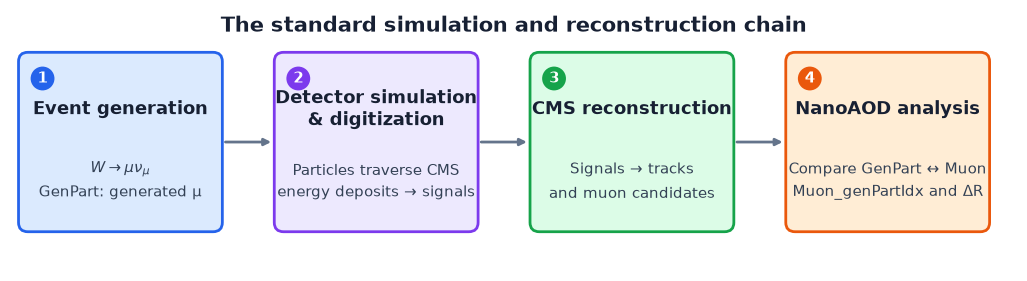

In [7]:
# @title From a generated event to a reconstructed muon
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 3.4))
ax.set(xlim=(0, 13), ylim=(0, 3.4))
ax.axis("off")

stages = [
    (0.15, "#dbeafe", "#2563eb", "Event generation", r"$W\to\mu\nu_\mu$" + "\nGenPart: generated μ"),
    (3.45, "#ede9fe", "#7c3aed", "Detector simulation\n& digitization", "Particles traverse CMS\nenergy deposits → signals"),
    (6.75, "#dcfce7", "#16a34a", "CMS reconstruction", "Signals → tracks\nand muon candidates"),
    (10.05, "#ffedd5", "#ea580c", "NanoAOD analysis", "Compare GenPart ↔ Muon\nMuon_genPartIdx and ΔR"),
]
box_width, box_height, box_y = 2.55, 2.25, 0.55

for number, (x, fill, edge, title, detail) in enumerate(stages, start=1):
    ax.add_patch(FancyBboxPatch(
        (x, box_y), box_width, box_height,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        facecolor=fill, edgecolor=edge, linewidth=2,
    ))
    ax.text(x + 0.27, box_y + box_height - 0.30, str(number), ha="center", va="center",
            color="white", fontsize=11, fontweight="bold",
            bbox={"boxstyle": "circle,pad=0.28", "facecolor": edge, "edgecolor": "none"})
    ax.text(x + box_width / 2, box_y + 1.55, title, ha="center", va="center",
            fontsize=13, fontweight="bold", color="#172033")
    ax.text(x + box_width / 2, box_y + 0.62, detail, ha="center", va="center",
            fontsize=11, linespacing=1.5, color="#334155")

for (x, *_), (next_x, *__) in zip(stages[:-1], stages[1:]):
    ax.annotate("", xy=(next_x - 0.08, box_y + box_height / 2),
                xytext=(x + box_width + 0.08, box_y + box_height / 2),
                arrowprops={"arrowstyle": "-|>", "color": "#64748b", "lw": 2,
                            "shrinkA": 0, "shrinkB": 0})

ax.text(6.5, 3.18, "The standard simulation and reconstruction chain",
        ha="center", va="center", fontsize=15, fontweight="bold", color="#172033")
plt.show()

For simulated events, the generator provides a reference description, often called **truth**. CMS then simulates how the generated particles pass through the detector, converts the simulated energy deposits into electronic signals, and applies the same reconstruction algorithms used for real collision data. NanoAOD retains both selected generator information and reconstructed objects, so we can compare the two. Real collision data do not have a `GenPart` truth record.

The NanoAOD branch `Muon_genPartIdx` is an index into `GenPart` for a reconstructed muon's generator match. We use the stored association first, then calculate

$$\Delta R=\sqrt{(\Delta\eta)^2+(\Delta\phi)^2}$$

as a diagnostic of angular agreement. The azimuthal angle $\phi$ goes around the beam axis, while pseudorapidity $\eta$ describes the direction relative to the beam; a small $\Delta R$ means two directions are close in the detector. Here $\Delta\phi$ is wrapped into $[-\pi,\pi]$ because angles differing by almost $2\pi$ point in almost the same direction. The stored index defines the match; $\Delta R$ checks how closely the two matched directions agree.

All direct muon events with a stored match: 29,433 / 44,206
For truth muons with pT > 15 GeV and |η| < 2.4: 26,043 / 26,079
Median pT response: 0.9995; central-68% half-width: 0.0169


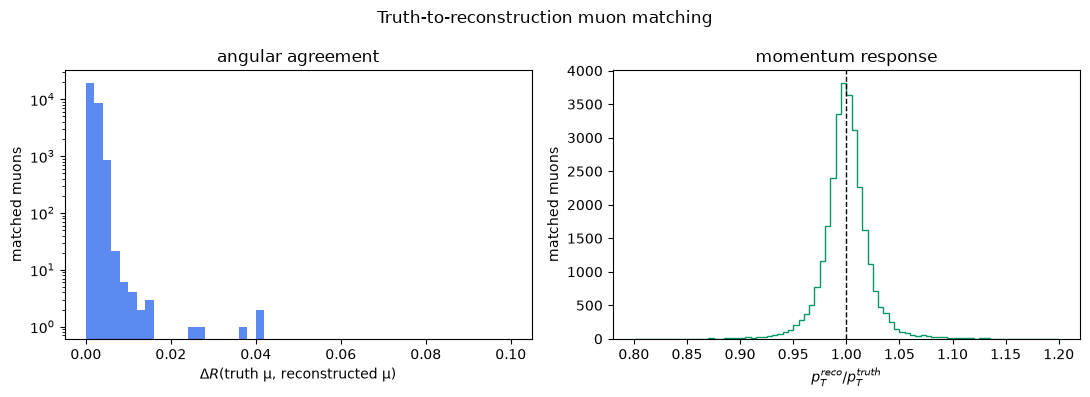

In [8]:
# Reduce the jagged collections to one truth and one matched reconstructed muon per event.
selected = ak.to_numpy(analysis_mask)
gen_mu_pt = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_pt[gen_mu_mask]), np.nan)[selected])
gen_mu_eta = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_eta[gen_mu_mask]), np.nan)[selected])
gen_mu_phi = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_phi[gen_mu_mask]), np.nan)[selected])
reco_mu_pt = ak.to_numpy(ak.fill_none(ak.firsts(data.Muon_pt[matched_reco_muon]), np.nan)[selected])
reco_mu_eta = ak.to_numpy(ak.fill_none(ak.firsts(data.Muon_eta[matched_reco_muon]), np.nan)[selected])
reco_mu_phi = ak.to_numpy(ak.fill_none(ak.firsts(data.Muon_phi[matched_reco_muon]), np.nan)[selected])
assert np.all(np.isfinite([gen_mu_pt, gen_mu_eta, gen_mu_phi, reco_mu_pt, reco_mu_eta, reco_mu_phi]))

# ΔR checks angular agreement; pT(reco)/pT(truth) measures the momentum response.
match_dr = delta_r(reco_mu_eta, reco_mu_phi, gen_mu_eta, gen_mu_phi)
pt_response = reco_mu_pt / gen_mu_pt
response_q16, response_median, response_q84 = np.quantile(pt_response, [0.16, 0.50, 0.84])
response_half_width = 0.5 * (response_q84 - response_q16)

# Separate detector acceptance from the existence of any stored truth match.
gen_mu_pt_event = ak.firsts(data.GenPart_pt[gen_mu_mask])
gen_mu_eta_event = ak.firsts(data.GenPart_eta[gen_mu_mask])
in_acceptance = mu_channel & (gen_mu_pt_event > 15) & (abs(gen_mu_eta_event) < 2.4)
print(f"All direct muon events with a stored match: {int(ak.sum(analysis_mask)):,} / {int(ak.sum(mu_channel)):,}")
print(f"For truth muons with pT > 15 GeV and |η| < 2.4: {int(ak.sum(in_acceptance & has_reco_match)):,} / {int(ak.sum(in_acceptance)):,}")
print(f"Median pT response: {response_median:.4f}; central-68% half-width: {response_half_width:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(match_dr, bins=np.linspace(0, 0.10, 51), color="#2563eb", histtype="stepfilled", alpha=0.75)
axes[0].set(xlabel="$\Delta R$(truth μ, reconstructed μ)", ylabel="matched muons", yscale="log", title="angular agreement")
axes[1].hist(pt_response, bins=np.linspace(0.8, 1.2, 81), color="#059669", histtype="step")
axes[1].axvline(1, color="black", linestyle="--", linewidth=1)
axes[1].set(xlabel="$p_T^{reco}/p_T^{truth}$", ylabel="matched muons", title="momentum response")
fig.suptitle("Truth-to-reconstruction muon matching")
fig.tight_layout()
plt.show()

> **Takeaway:** a missing stored match does not necessarily mean that CMS failed to detect the muon. The muon may be outside the detector's angular coverage, have too little $p_T$, or fail a NanoAOD storage requirement. Within the central, energetic region, almost every truth muon in this file has a stored match. This is therefore **not** a complete detector-efficiency measurement.

The $p_T$ ratio is the **momentum response**. A distribution centred near 1 means that reconstruction is approximately correct on average; its width shows the event-to-event spread in this selected sample. Stricter track-quality or muon-identification requirements can remove poorly measured candidates and make the distribution narrower, but they also discard events. This changes the selected sample rather than the detector's intrinsic resolution.

From here on, “selected events” means direct $W\to\mu\nu$ events with one stored generator-matched muon. We deliberately apply no muon identification, isolation, or trigger requirement: the goal is to isolate the truth-to-reconstruction concepts, not to reproduce a full CMS analysis.

## 6. The neutrino becomes missing transverse momentum

Recall that “transverse” means perpendicular to the proton beams. The two incoming protons have essentially zero total momentum in this plane. The colliding quarks or gluons inside the protons—called **partons**—carry unknown fractions of the protons' longitudinal momentum, so transverse momentum balance is especially useful at the LHC.

Because neutrinos interact only weakly, a neutrino usually passes through CMS without depositing measurable energy. The detector instead infers the missing transverse-momentum vector

$$\vec p_T^{\,miss}\simeq-\sum_{\mathrm{reconstructed\ particles}}\vec p_T.$$

NanoAOD uses the historical name `MET` (“missing transverse energy”) for reconstructed missing transverse momentum. The actual CMS value includes particle-flow reconstruction and calibration details; the equation above states the vector-balance idea. `GenMET` is the generator-level counterpart. It is usually almost identical to the W neutrino in this sample, but it is an event-level quantity rather than a pointer to that one neutrino.

In the one-event plot below, the truth and reconstructed muon vectors are so similar that their lines nearly overlap. Endpoint circles denote truth and crosses denote reconstruction, so both remain visible without shifting either vector.

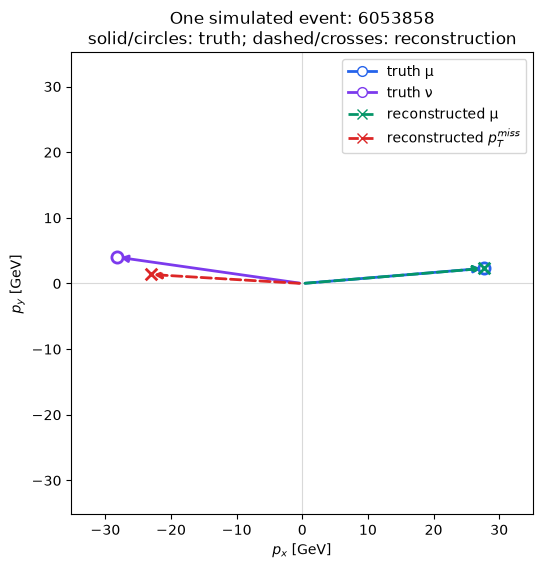

In [9]:
# Compare generator and reconstructed transverse vectors in the same event.
vector_event = example_index
event_gen_mu_pt = float(ak.firsts(data.GenPart_pt[gen_mu_mask])[vector_event])
event_gen_mu_phi = float(ak.firsts(data.GenPart_phi[gen_mu_mask])[vector_event])
event_gen_nu_pt = float(ak.firsts(data.GenPart_pt[gen_nu_mask])[vector_event])
event_gen_nu_phi = float(ak.firsts(data.GenPart_phi[gen_nu_mask])[vector_event])
event_reco_mu_pt = float(ak.firsts(data.Muon_pt[matched_reco_muon])[vector_event])
event_reco_mu_phi = float(ak.firsts(data.Muon_phi[matched_reco_muon])[vector_event])

vectors = [
    ("truth μ", event_gen_mu_pt, event_gen_mu_phi, "#2563eb", "-", "o"),
    ("truth ν", event_gen_nu_pt, event_gen_nu_phi, "#7c3aed", "-", "o"),
    ("reconstructed μ", event_reco_mu_pt, event_reco_mu_phi, "#059669", "--", "x"),
    ("reconstructed $p_T^{miss}$", float(data.MET_pt[vector_event]), float(data.MET_phi[vector_event]), "#dc2626", "--", "x"),
]
fig, ax = plt.subplots(figsize=(6, 6))
components = []
# Convert (pT, φ) to Cartesian components for plotting.
for label, pt_value, phi_value, color, line_style, marker in vectors:
    px_value, py_value = pt_value * np.cos(phi_value), pt_value * np.sin(phi_value)
    components.extend([abs(px_value), abs(py_value)])
    ax.annotate(
        "", xy=(px_value, py_value), xytext=(0, 0),
        arrowprops={"arrowstyle": "-|>", "color": color, "lw": 2, "linestyle": line_style},
    )
    if marker == "o":
        ax.scatter(px_value, py_value, marker=marker, s=65, facecolors="white", edgecolors=color, linewidths=2, zorder=5)
    else:
        ax.scatter(px_value, py_value, marker=marker, s=70, color=color, linewidths=2, zorder=6)
    ax.plot(
        [], [], color=color, linestyle=line_style, linewidth=2, marker=marker,
        markerfacecolor="white" if marker == "o" else color, markeredgecolor=color,
        markersize=7, label=label,
    )
limit = 1.25 * max(components)
ax.set(xlim=(-limit, limit), ylim=(-limit, limit), xlabel="$p_x$ [GeV]", ylabel="$p_y$ [GeV]")
ax.axhline(0, color="0.85", linewidth=0.8); ax.axvline(0, color="0.85", linewidth=0.8)
ax.set_aspect("equal"); ax.legend(); ax.set_title(
    f"One simulated event: {int(data.event[vector_event])}\n"
    "solid/circles: truth; dashed/crosses: reconstruction"
)
plt.show()

Median GenMET / W-neutrino pT: 1.000
Median |Δφ|(GenMET, W neutrino): 0.0010 rad


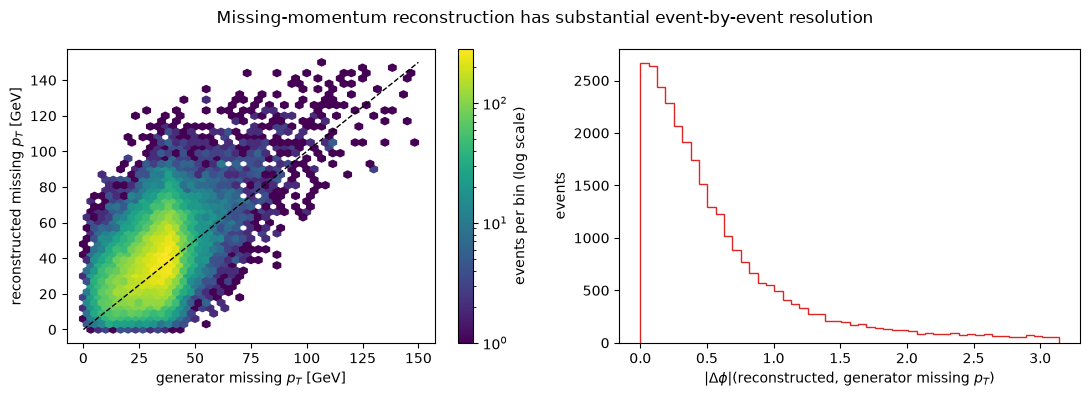

In [10]:
# Extract one hard-process neutrino and the two event-level missing-momentum definitions.
gen_nu_pt = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_pt[gen_nu_mask]), np.nan)[selected])
gen_nu_eta = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_eta[gen_nu_mask]), np.nan)[selected])
gen_nu_phi = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_phi[gen_nu_mask]), np.nan)[selected])
gen_nu_mass = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_mass[gen_nu_mask]), np.nan)[selected])
gen_mu_mass = ak.to_numpy(ak.fill_none(ak.firsts(data.GenPart_mass[gen_mu_mask]), np.nan)[selected])
genmet_pt = ak.to_numpy(data.GenMET_pt[selected])
genmet_phi = ak.to_numpy(data.GenMET_phi[selected])
met_pt = ak.to_numpy(data.MET_pt[selected])
met_phi = ak.to_numpy(data.MET_phi[selected])
assert np.all(np.isfinite([gen_nu_pt, gen_nu_eta, gen_nu_phi, gen_nu_mass, gen_mu_mass, genmet_pt, genmet_phi, met_pt, met_phi]))

print(f"Median GenMET / W-neutrino pT: {np.median(genmet_pt / gen_nu_pt):.3f}")
print(f"Median |Δφ|(GenMET, W neutrino): {np.median(abs(delta_phi(genmet_phi, gen_nu_phi))):.4f} rad")

# Compare reconstructed MET with generator-level missing momentum, not just one particle.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
hb = axes[0].hexbin(genmet_pt, met_pt, extent=(0, 150, 0, 150), gridsize=45, bins="log", mincnt=1)
axes[0].plot([0, 150], [0, 150], "k--", linewidth=1)
axes[0].set(xlabel="generator missing $p_T$ [GeV]", ylabel="reconstructed missing $p_T$ [GeV]")
fig.colorbar(hb, ax=axes[0], label="events per bin (log scale)")
axes[1].hist(abs(delta_phi(met_phi, genmet_phi)), bins=np.linspace(0, np.pi, 51), histtype="step", color="#dc2626")
axes[1].set(xlabel="$|\Delta\phi|$(reconstructed, generator missing $p_T$)", ylabel="events")
fig.suptitle("Missing-momentum reconstruction has substantial event-by-event resolution")
fig.tight_layout()
plt.show()

> **Takeaway:** missing momentum is a detector-wide balance measurement. Calling it “the neutrino momentum” is often a useful approximation, but not its definition.

## 7. The missing longitudinal component

For a system with total four-vector $(E,p_x,p_y,p_z)$, its invariant mass is

$$m^2=E^2-p_x^2-p_y^2-p_z^2.$$

Reconstructing the W invariant mass therefore requires all components of both decay products. Generator truth supplies the neutrino's $\eta$, so we can calculate $p_z^\nu$ and the full $\mu\nu$ invariant mass. Reconstructed missing momentum contains only `pt` ($p_T$) and `phi` ($\phi$). Because the incoming partons carry unknown fractions of the proton momenta, longitudinal momentum conservation cannot determine $p_z^\nu$ event by event.

<details><summary>What exactly is the “truth mass” here?</summary>It is the invariant mass built from the stable hard-interaction muon and neutrino stored in `GenPart`. Photons radiated by the muon are not added back.</details>

We must not quietly set $p_z^\nu=0$. Instead, treating the muon and neutrino as nearly massless, we use

$$m_T=\sqrt{2p_T^\mu p_T^{miss}\left(1-\cos\Delta\phi\right)}.$$

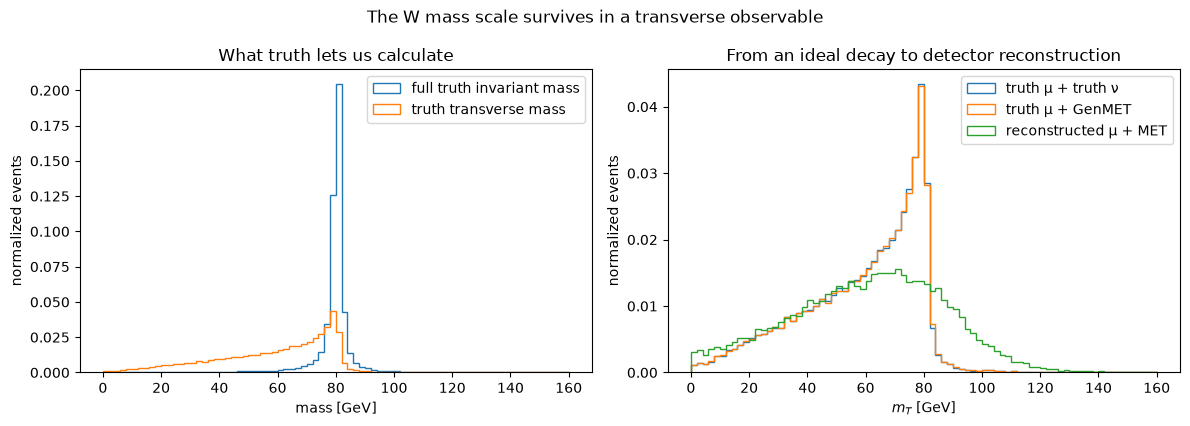

In [11]:
# Build (E, px, py, pz) from NanoAOD's (pT, η, φ, mass) coordinates.
def four_vector(pt, eta, phi, mass):
    return np.column_stack([
        np.sqrt((pt * np.cosh(eta))**2 + mass**2),
        pt * np.cos(phi), pt * np.sin(phi), pt * np.sinh(eta),
    ])

mu_p4 = four_vector(gen_mu_pt, gen_mu_eta, gen_mu_phi, gen_mu_mass)
nu_p4 = four_vector(gen_nu_pt, gen_nu_eta, gen_nu_phi, gen_nu_mass)
truth_total = mu_p4 + nu_p4
truth_mass_squared = truth_total[:, 0]**2 - np.sum(truth_total[:, 1:]**2, axis=1)
truth_invariant_mass = np.sqrt(np.maximum(truth_mass_squared, 0))

# Replace the truth neutrino step by step with GenMET and reconstructed MET.
truth_mt = transverse_mass(gen_mu_pt, gen_mu_phi, gen_nu_pt, gen_nu_phi)
gen_observable_mt = transverse_mass(gen_mu_pt, gen_mu_phi, genmet_pt, genmet_phi)
reco_mt = transverse_mass(reco_mu_pt, reco_mu_phi, met_pt, met_phi)

bins = np.linspace(0, 160, 81)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].hist(truth_invariant_mass, bins=bins, histtype="step", density=True, label="full truth invariant mass")
axes[0].hist(truth_mt, bins=bins, histtype="step", density=True, label="truth transverse mass")
axes[0].set(xlabel="mass [GeV]", ylabel="normalized events", title="What truth lets us calculate")
axes[0].legend()

axes[1].hist(truth_mt, bins=bins, histtype="step", density=True, label="truth μ + truth ν")
axes[1].hist(gen_observable_mt, bins=bins, histtype="step", density=True, label="truth μ + GenMET")
axes[1].hist(reco_mt, bins=bins, histtype="step", density=True, label="reconstructed μ + MET")
axes[1].set(xlabel="$m_T$ [GeV]", ylabel="normalized events", title="From an ideal decay to detector reconstruction")
axes[1].legend()
fig.suptitle("The W mass scale survives in a transverse observable")
fig.tight_layout()
plt.show()

## 8. Takeaways

- Simulation truth tells us what was generated; reconstruction tells us what the detector inferred.
- A neutrino is not measured directly. Its presence is inferred through transverse momentum imbalance.
- Energy and three momentum components form a four-vector; $p_T$ is the momentum projected perpendicular to the beams.
- At a proton collider, the unknown incoming parton momenta make transverse observables especially useful.
- The truth $\mu\nu$ invariant mass clusters near the W mass. The transverse mass retains a characteristic edge near the W mass scale without assuming a neutrino $p_z$.
- The W's natural mass spread, additional invisible particles, and detector resolution blur the idealized edge and can produce larger values.

## Exercises for further study

### 1. Build the angular functions
Rewrite `delta_phi` and `transverse_mass` without looking at the toolbox. Why must $\Delta\phi$ be wrapped?

<details><summary>Hint and expected result</summary>Angles differing by nearly $2\pi$ point in nearly the same direction. Wrap into $[-\pi,\pi]$ before using the difference. The reconstructed $m_T$ distribution should match the final plot.</details>

### 2. Match by nearest $\Delta R$
For every truth muon, find the closest reconstructed muon. Compare your result with `Muon_genPartIdx` for thresholds such as $\Delta R<0.1$ and $0.2$.

<details><summary>Hint and expected result</summary>Form all truth–reco pairs within each event, calculate $\Delta R$, and take the minimum. Most matches agree, but the stored CMS association is the reference for this exercise; nearest $\Delta R$ is only our approximation.</details>

### 3. Acceptance versus efficiency
Plot the fraction of truth muons with a stored match versus truth $p_T$ and $\eta$.

<details><summary>Expected result</summary>The fraction falls at low $p_T$ and outside the central detector. Restricting to $p_T>15$ GeV and $|\eta|<2.4$ gives a very high matched fraction in this sample.</details>

### 4. What makes MET difficult?
Study the MET response or angular resolution versus the number of reconstructed jets (`nJet`) or the simulated amount of pileup (`Pileup_nTrueInt`).

<details><summary>Expected result</summary>Additional reconstructed activity makes the vector balance more complicated; resolution is an event-wide property, not a neutrino-detector resolution.</details>

### 5. Is the decay back-to-back?
Plot $|\Delta\phi(\mu,\nu)|$ against the generated W transverse momentum or jet multiplicity.

<details><summary>Expected result</summary>The decay products are back-to-back in the W rest frame, not generally in the laboratory transverse plane. W recoil changes their opening angle.</details>

### 6. Follow the tau channel
Select $W\to\tau\nu$ and find events with $\tau\to\mu\nu\nu$.

<details><summary>Expected result</summary>The muon is typically softer and several neutrinos contribute to missing momentum. Parent indices are needed to distinguish this from direct $W\to\mu\nu$.</details>

### 7. Advanced: solve for neutrino $p_z$
Impose $(p_\mu+p_\nu)^2=m_W^2$ and derive the quadratic equation for $p_z^\nu$.

<details><summary>Expected result</summary>There are generally two solutions; detector resolution can also make the discriminant negative. This illustrates why reconstructed analyses need an explicit prescription rather than a unique measured value.</details>